In [ ]:
import pandas as pd
from unidecode import unidecode

: 

In [122]:
df_french = pd.read_csv("data/french_top_10000.csv",header=1,skipinitialspace=True)
df_french = df_french[["lemme"]]
df_french['lemme'] = df_french['lemme'].apply(lambda x: unidecode(x) if isinstance(x, str) else '')
df_english = pd.read_csv("data/english_top_10000.txt", header= None, names=["words"])
df_ten_words = pd.read_csv("data/words10.csv", )
df_ten_words.columns = df_ten_words.columns.str.strip()
for col in df_ten_words.select_dtypes(include='object'):
    df_ten_words[col] = (
        df_ten_words[col]
        .astype(str)
        .str.strip()
        .apply(lambda x: unidecode(x) if isinstance(x, str) else '')
        .str.lower()
    )


/tmp/ipykernel_37016/2373950144.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_ten_words.select_dtypes(include='object'):


In [104]:
df_ten_words.info()


<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   model     144 non-null    str  
 1   language  144 non-null    str  
 2   1         144 non-null    str  
 3   2         144 non-null    str  
 4   3         144 non-null    str  
 5   4         144 non-null    str  
 6   5         144 non-null    str  
 7   6         144 non-null    str  
 8   7         144 non-null    str  
 9   8         144 non-null    str  
 10  9         144 non-null    str  
 11  10        144 non-null    str  
 12  genre     144 non-null    str  
 13  age       144 non-null    str  
dtypes: str(14)
memory usage: 28.6 KB


In [84]:
def prepare_lexicons(limit):
    """
    Prépare les sets de mots les plus fréquents à partir des datasets.
    
    Arguments:
        X_english: nombre de mots à prendre pour English
        X_usa: nombre de mots à prendre pour USA
        X_french: nombre de mots à prendre pour French
    
    Retour:
        dict de sets { "english": set(...), "usa": set(...), "french": set(...) }
    """
    lex_dict = {
        "english": set(df_english["words"].head(limit)),
        "french": set(df_french["lemme"].head(limit))
    }
    return lex_dict

In [120]:
def compute_scores_all(row, lex_dict):
    words = row[[str(i) for i in range(1, 11)]].tolist()
    lang = str(row["language"]).lower()
    
    if lang == "english":
        score_english = sum(1 for w in words if w in lex_dict["english"])
        return score_english

    elif lang == "french":
        score_french = sum(1 for w in words if w in lex_dict["french"])
        return score_french
    
    else:
        # autre langue
        print("error lang")
        return None


In [118]:
# préparer les lexiques pour X mots
lex_dict = prepare_lexicons(limit=100000)

# calculer les scores pour toutes les lignes
df_scores = df_ten_words.apply(lambda row: compute_scores_all(row, lex_dict), axis=1)

# ajouter les colonnes au DataFrame original
df_ten_words['score']=df_scores

['pebble', 'thunder', 'pillow', 'forest', 'mirror', 'bread', 'shadow', 'ocean', 'silence', 'ladder']
['mountain', 'spoon', 'thunder', 'library', 'childhood', 'ocean', 'mirror', 'bread', 'shadow', 'melody']
['mountain', 'toothbrush', 'democracy', 'kitten', 'thunder', 'pillow', 'rainbow', 'hunger', 'library', 'shadow']
['montagne', 'chaise', 'tempete', 'parfum', 'miroir', 'silence', 'riviere', 'enfance', 'liberte', 'sourire']
['arbre', 'liberte', 'cuillere', 'tempete', 'parfum', 'horloge', 'sable', 'musique', 'fenetre', 'sourire']
['montagne', 'chaise', 'liberte', 'nuage', 'parfum', 'horloge', 'riviere', 'secret', 'sable', 'sourire']
['montagne', 'cuillere', 'liberte', 'nuage', 'horloge', 'foret', 'sourire', 'valise', 'tempete', 'silence']
['montagne', 'cuillere', 'liberte', 'orage', 'enfance', 'parfum', 'miroir', 'foret', 'silence', 'horloge']
['mountain', 'justice', 'spoon', 'thunder', 'childhood', 'ocean', 'mirror', 'freedom', 'bread', 'shadow']
['mountain', 'teaspoon', 'thunder', 'fr

In [119]:
df_ten_words

,model,language,1,2,3,4,5,6,7,8,9,10,genre,age,score
0,gpt_53_chat,english,pebble,thunder,pillow,forest,mirror,bread,shadow,ocean,silence,ladder,none,none,9
1,gpt_53_chat,english,mountain,spoon,thunder,library,childhood,ocean,mirror,bread,shadow,melody,none,none,8
2,gpt_53_chat,english,mountain,toothbrush,democracy,kitten,thunder,pillow,rainbow,hunger,library,shadow,none,none,8
3,gpt_53_chat,french,montagne,chaise,tempete,parfum,miroir,silence,riviere,enfance,liberte,sourire,none,none,10
4,gpt_53_chat,french,arbre,liberte,cuillere,tempete,parfum,horloge,sable,musique,fenetre,sourire,none,none,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,human,french,maison,jardin,chaisse,bouteille,poele,tabouret,sol,table,mer,clavier,none,33,9
140,human,french,technologie,sprit,donnees,agilite,social,equipe,gestion,empathie,engineer,connection,none,none,4
141,human,french,kiwi,ski,crabe,nuage,magnolia,cours,bucle,grippe,riviere,hopital,none,42,7
142,human,french,paysage,ordinateur,film,tournevis,maison,ciel,moteur,velo,chaussure,col,none,27,10


In [123]:
def compute_word_scores(df, limit=10000):
    """
    Pour chaque ligne du DataFrame `df` contenant 10 mots et une colonne 'language',
    calcule les scores par lexique (français / anglais / US) selon la langue,
    et retourne le DataFrame enrichi avec une colonne 'score' (ou plusieurs scores si nécessaire).
    """
    df = df.copy()
    # Préparer les lexiques
    lex_dict = prepare_lexicons(limit=limit)

    # calculer les scores pour toutes les lignes
    df_scores = df.apply(lambda row: compute_scores_all(row, lex_dict), axis=1)

    # ajouter les colonnes au DataFrame original
    df['score'] = df_scores

    return df

In [125]:
resultat = compute_word_scores(df_ten_words, 5000)
resultat

,model,language,1,2,3,4,5,6,7,8,9,10,genre,age,score
0,gpt_53_chat,english,pebble,thunder,pillow,forest,mirror,bread,shadow,ocean,silence,ladder,none,none,5
1,gpt_53_chat,english,mountain,spoon,thunder,library,childhood,ocean,mirror,bread,shadow,melody,none,none,6
2,gpt_53_chat,english,mountain,toothbrush,democracy,kitten,thunder,pillow,rainbow,hunger,library,shadow,none,none,4
3,gpt_53_chat,french,montagne,chaise,tempete,parfum,miroir,silence,riviere,enfance,liberte,sourire,none,none,10
4,gpt_53_chat,french,arbre,liberte,cuillere,tempete,parfum,horloge,sable,musique,fenetre,sourire,none,none,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,human,french,maison,jardin,chaisse,bouteille,poele,tabouret,sol,table,mer,clavier,none,33,6
140,human,french,technologie,sprit,donnees,agilite,social,equipe,gestion,empathie,engineer,connection,none,none,3
141,human,french,kiwi,ski,crabe,nuage,magnolia,cours,bucle,grippe,riviere,hopital,none,42,7
142,human,french,paysage,ordinateur,film,tournevis,maison,ciel,moteur,velo,chaussure,col,none,27,9


In [129]:
limits = [100, 500, 1000, 2000, 5000, 7500, 10000]

df_scores_all = df_ten_words.copy()

for lim in limits:
    df_scores_all = compute_word_scores(df_scores_all, limit=lim)
    # renommer la colonne 'score' pour garder la trace de la limite
    df_scores_all = df_scores_all.rename(columns={'score': f'score_{lim}'})

df_scores_all

,model,language,1,2,3,4,5,6,7,8,...,10,genre,age,score_100,score_500,score_1000,score_2000,score_5000,score_7500,score_10000
0,gpt_53_chat,english,pebble,thunder,pillow,forest,mirror,bread,shadow,ocean,...,ladder,none,none,0,0,0,1,5,6,9
1,gpt_53_chat,english,mountain,spoon,thunder,library,childhood,ocean,mirror,bread,...,melody,none,none,0,1,1,2,6,7,8
2,gpt_53_chat,english,mountain,toothbrush,democracy,kitten,thunder,pillow,rainbow,hunger,...,shadow,none,none,0,1,1,2,4,5,8
3,gpt_53_chat,french,montagne,chaise,tempete,parfum,miroir,silence,riviere,enfance,...,sourire,none,none,0,0,2,9,10,10,10
4,gpt_53_chat,french,arbre,liberte,cuillere,tempete,parfum,horloge,sable,musique,...,sourire,none,none,0,1,4,6,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,human,french,maison,jardin,chaisse,bouteille,poele,tabouret,sol,table,...,clavier,none,33,0,1,3,6,6,8,9
140,human,french,technologie,sprit,donnees,agilite,social,equipe,gestion,empathie,...,connection,none,none,0,0,1,2,3,4,4
141,human,french,kiwi,ski,crabe,nuage,magnolia,cours,bucle,grippe,...,hopital,none,42,0,0,2,4,7,7,7
142,human,french,paysage,ordinateur,film,tournevis,maison,ciel,moteur,velo,...,col,none,27,0,2,4,7,9,10,10


In [132]:
df_result = resultat[["model","language","score"]].copy()
df_result

df_result_all = df_scores_all[["model","language","score_100","score_500","score_1000","score_2000","score_5000","score_7500","score_10000"]]
df_result_all

,model,language,score_100,score_500,score_1000,score_2000,score_5000,score_7500,score_10000
0,gpt_53_chat,english,0,0,0,1,5,6,9
1,gpt_53_chat,english,0,1,1,2,6,7,8
2,gpt_53_chat,english,0,1,1,2,4,5,8
3,gpt_53_chat,french,0,0,2,9,10,10,10
4,gpt_53_chat,french,0,1,4,6,10,10,10
...,...,...,...,...,...,...,...,...,...
139,human,french,0,1,3,6,6,8,9
140,human,french,0,0,1,2,3,4,4
141,human,french,0,0,2,4,7,7,7
142,human,french,0,2,4,7,9,10,10


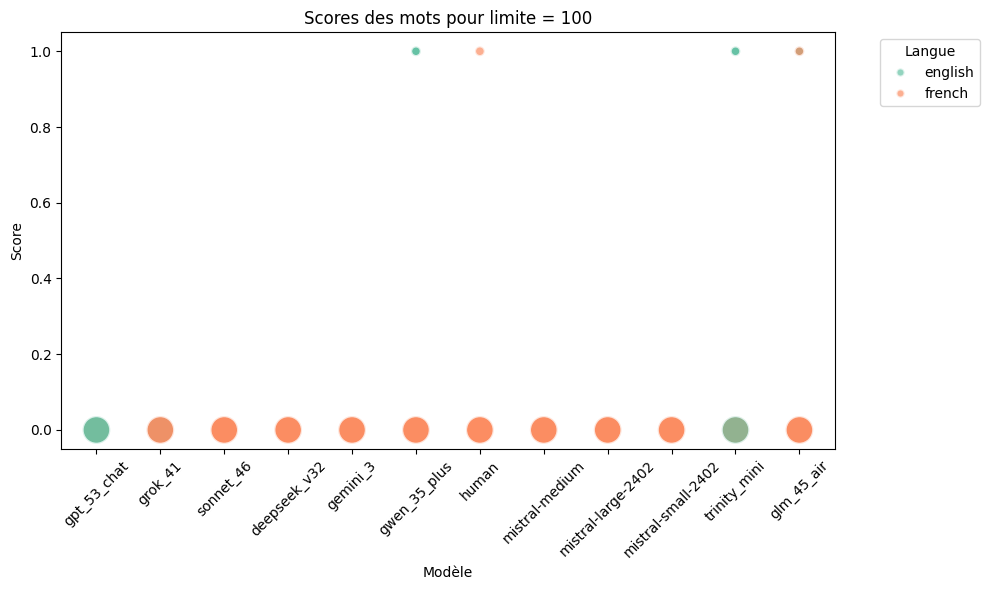

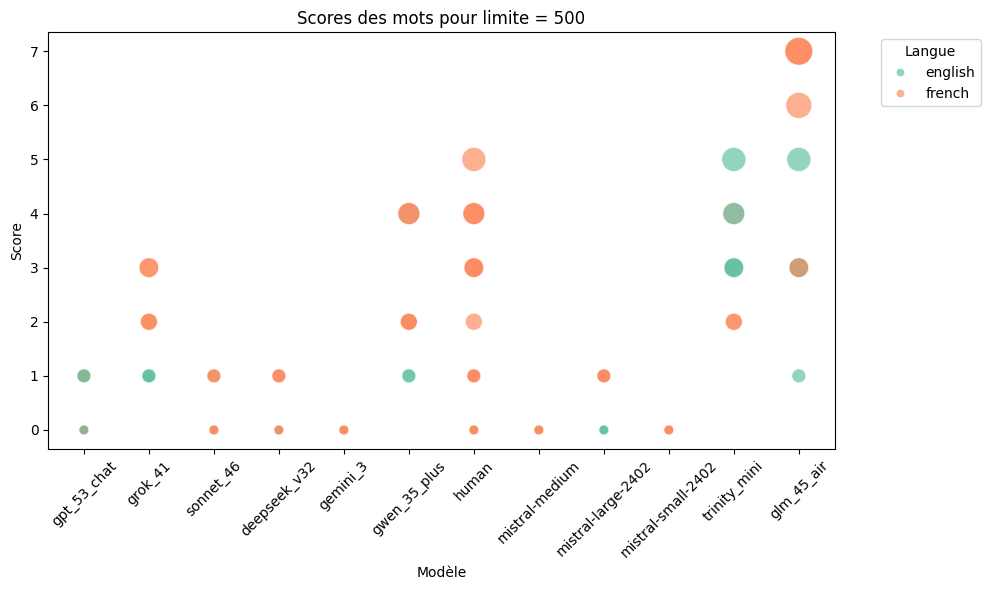

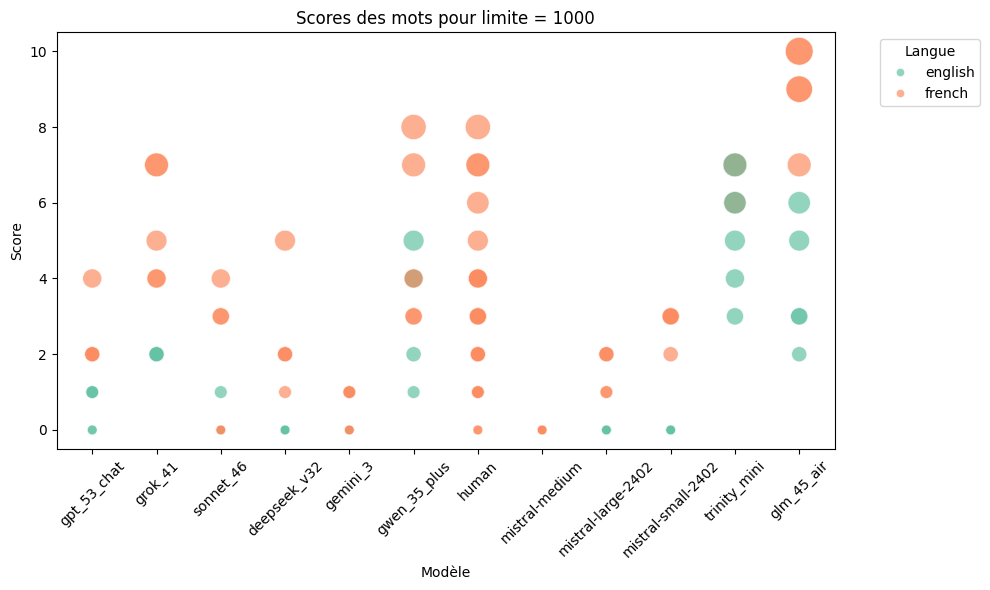

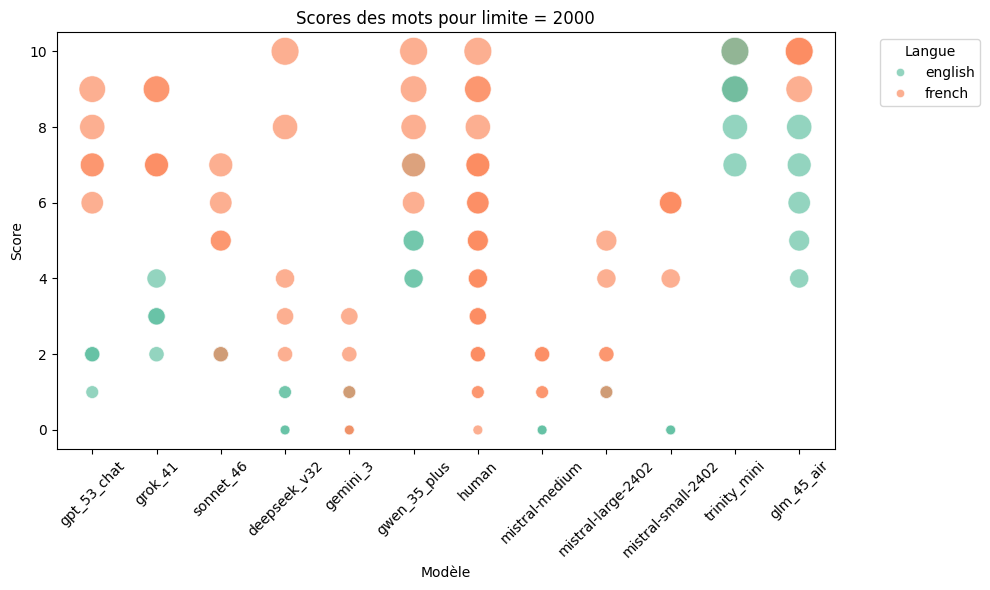

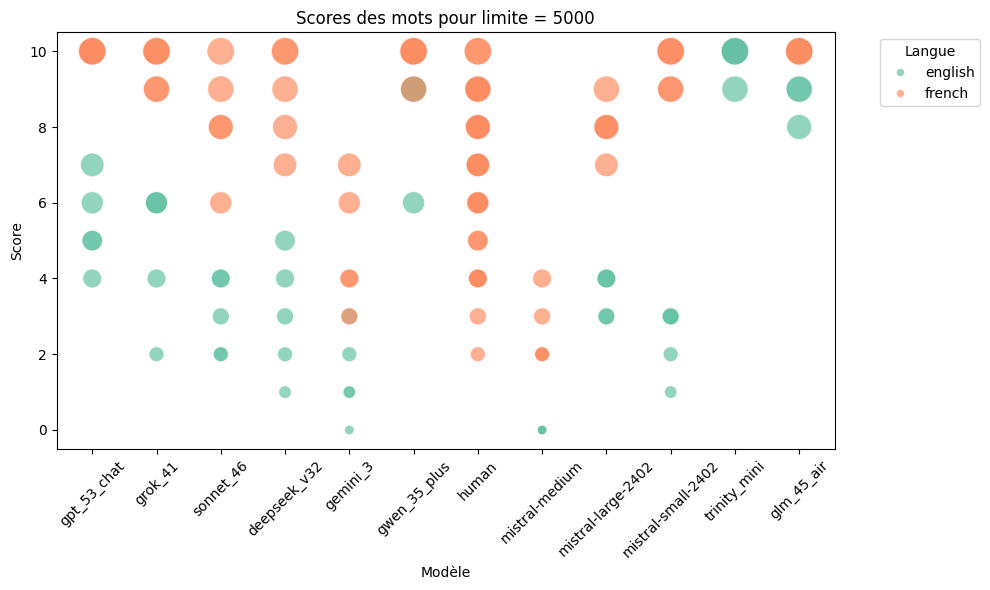

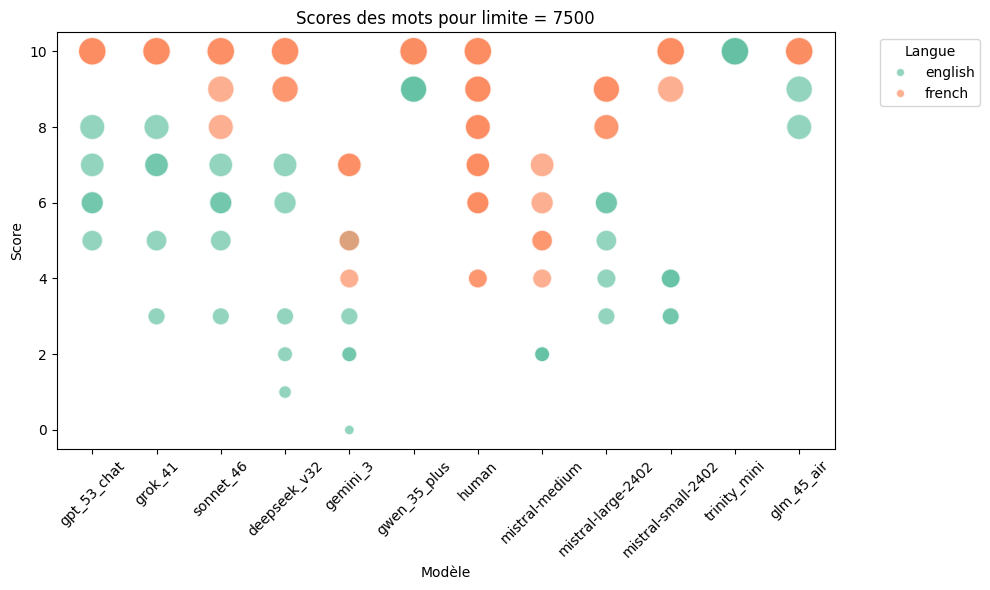

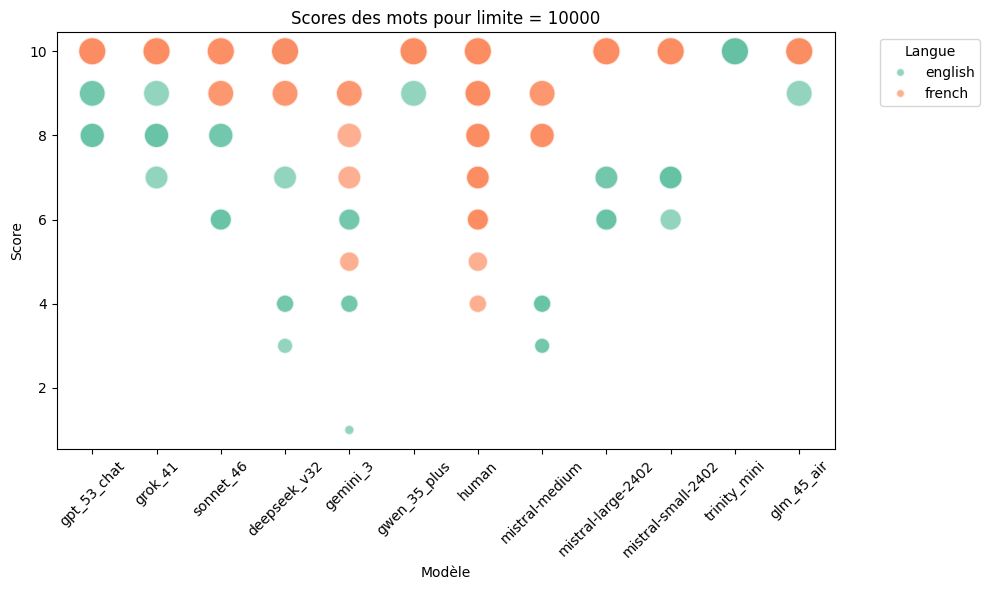

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

limits = [100, 500, 1000, 2000, 5000, 7500, 10000]

for lim in limits:
    score_col = f'score_{lim}'  # nom de la colonne des scores pour cette limite
    size_col = f'score_{lim}'      # colonne pour la taille des points (ex: nb de mots valides)

    plt.figure(figsize=(10, 6))
    scatter = sns.scatterplot(
        data=df_scores_all,
        x='model',          # axe X : type de modèle
        y=score_col,        # axe Y : score
        hue='language',     # couleur selon la langue
        size=size_col,      # taille des points selon la quantité
        palette='Set2',
        sizes=(50, 400),    # min et max des tailles
        alpha=0.7
    )
    plt.title(f'Scores des mots pour limite = {lim}')
    plt.ylabel('Score')
    plt.xlabel('Modèle')
    plt.xticks(rotation=45)

    # Créer une légende pour hue seulement
    handles, labels = scatter.get_legend_handles_labels()
    
    # Récupérer uniquement les handles correspondant au hue
    hue_labels = df_scores_all['language'].unique()
    hue_handles = [h for h, l in zip(handles, labels) if l in hue_labels]
    hue_labels = [l for l in labels if l in hue_labels]
    
    scatter.legend(
        handles=hue_handles,
        labels=hue_labels,
        title='Langue',
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )
    plt.tight_layout()
    plt.show()